In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../../3.1 UNZIP_ME_FOR_NOTEBOOKS_V4/DATA/Ames_Housing_Data.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2930 non-null   int64  
 1   MS SubClass      2930 non-null   int64  
 2   MS Zoning        2930 non-null   str    
 3   Lot Frontage     2440 non-null   float64
 4   Lot Area         2930 non-null   int64  
 5   Street           2930 non-null   str    
 6   Alley            198 non-null    str    
 7   Lot Shape        2930 non-null   str    
 8   Land Contour     2930 non-null   str    
 9   Utilities        2930 non-null   str    
 10  Lot Config       2930 non-null   str    
 11  Land Slope       2930 non-null   str    
 12  Neighborhood     2930 non-null   str    
 13  Condition 1      2930 non-null   str    
 14  Condition 2      2930 non-null   str    
 15  Bldg Type        2930 non-null   str    
 16  House Style      2930 non-null   str    
 17  Overall Qual     2930 non

In [5]:
df.corr(numeric_only=True)["SalePrice"].sort_values()

PID               -0.246521
Enclosed Porch    -0.128787
Kitchen AbvGr     -0.119814
Overall Cond      -0.101697
MS SubClass       -0.085092
Low Qual Fin SF   -0.037660
Bsmt Half Bath    -0.035835
Yr Sold           -0.030569
Misc Val          -0.015691
BsmtFin SF 2       0.005891
3Ssn Porch         0.032225
Mo Sold            0.035259
Pool Area          0.068403
Screen Porch       0.112151
Bedroom AbvGr      0.143913
Bsmt Unf SF        0.182855
Lot Area           0.266549
2nd Flr SF         0.269373
Bsmt Full Bath     0.276050
Half Bath          0.285056
Open Porch SF      0.312951
Wood Deck SF       0.327143
Lot Frontage       0.357318
BsmtFin SF 1       0.432914
Fireplaces         0.474558
TotRms AbvGrd      0.495474
Mas Vnr Area       0.508285
Garage Yr Blt      0.526965
Year Remod/Add     0.532974
Full Bath          0.545604
Year Built         0.558426
1st Flr SF         0.621676
Total Bsmt SF      0.632280
Garage Area        0.640401
Garage Cars        0.647877
Gr Liv Area        0

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

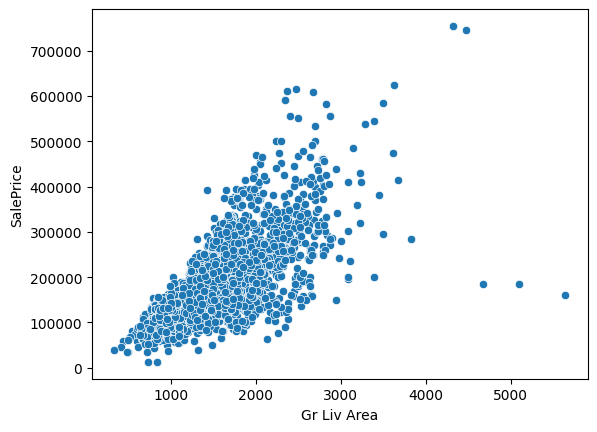

In [6]:
sns.scatterplot(data=df,x=df['Gr Liv Area'],y=df['SalePrice'])

In [7]:
drop_cols = df[(df['Gr Liv Area'] > 4000) & (df['SalePrice'] < 300000)].index

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

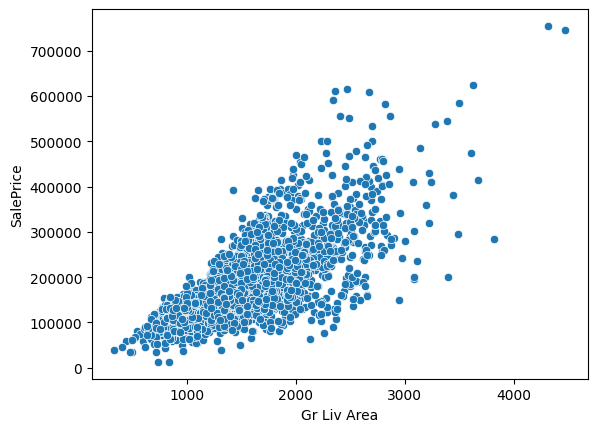

In [8]:
df = df.drop(drop_cols,axis=0)


sns.scatterplot(data=df,x=df['Gr Liv Area'],y=df['SalePrice'])

In [9]:
df_nums = df.select_dtypes(exclude='object')
df_obj = df.select_dtypes(include='object')

df_obj

C:\Users\kidus\AppData\Local\Temp\ipykernel_41780\1915047885.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_obj = df.select_dtypes(include='object')


,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
0,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,Attchd,Fin,TA,TA,P,NaN,NaN,NaN,WD,Normal
1,RH,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,...,Attchd,Unf,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,NaN,NaN,Gar2,WD,Normal
3,RL,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,Attchd,Fin,TA,TA,Y,NaN,NaN,NaN,WD,Normal
4,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,Attchd,Fin,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,RL,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,Mitchel,Norm,...,Detchd,Unf,TA,TA,Y,NaN,GdPrv,NaN,WD,Normal
2926,RL,Pave,NaN,IR1,Low,AllPub,Inside,Mod,Mitchel,Norm,...,Attchd,Unf,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
2927,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,...,NaN,NaN,NaN,NaN,Y,NaN,MnPrv,Shed,WD,Normal
2928,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal


In [10]:
df_objs = pd.get_dummies(df_obj,drop_first=True)

df_objs

,MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM,Street_Pave,Alley_Pave,Lot Shape_IR2,Lot Shape_IR3,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
1,False,False,False,True,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
4,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2926,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2927,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2928,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False


In [11]:
final_df = pd.concat([df_nums,df_objs],axis=1)

In [ ]:
final_df.to_excel('../data/ames.xlsx')

<class 'pandas.DataFrame'>
Index: 2927 entries, 0 to 2929
Columns: 260 entries, PID to Sale Condition_Partial
dtypes: bool(222), float64(11), int64(27)
memory usage: 1.5 MB
